<a href="https://colab.research.google.com/github/MrCherveN/Machine-Learning--4-0_HomeTasks/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
import opendatasets as od
import pandas as pd
import numpy as np
import sys
import importlib
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, auc, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
import time
from sklearn.model_selection import RandomizedSearchCV

In [3]:
!git clone https://github.com/MrCherveN/Machine-Learning--4-0_HomeTasks.git

fatal: destination path 'Machine-Learning--4-0_HomeTasks' already exists and is not an empty directory.


In [4]:
sys.path.append('/content/Machine-Learning--4-0_HomeTasks/')

import process_bank_churn
importlib.reload(process_bank_churn)
from process_bank_churn import preprocess_data, preprocess_new_data

In [5]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4'
od.download(dataset_url)
data_dir = '/content/bank-customer-churn-prediction-dlu-course-c-4'
train_csv = data_dir + '/train.csv'

raw_df = pd.read_csv(train_csv)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-4" (use force=True to force download)


In [6]:
data = preprocess_data(raw_df)

In [7]:
X_train = data['train_X']
train_targets = data['train_y']
X_val = data['val_X']
val_targets = data['val_y']

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [8]:
model = KNeighborsClassifier()
model.fit(X_train, train_targets)

KNeighborsClassifier()

In [9]:
def evaluate_model(inputs, targets, model, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds, pos_label=1)
  print(f"F1 score {name}: {f1_score_:.2f}")

  y_pred_proba = model.predict_proba(inputs)
  y_pred_proba_1 = y_pred_proba[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba_1, pos_label=1)

  # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  return preds, y_pred_proba, roc_auc


def predict_and_plot(targets, preds, name=''):

    cf = confusion_matrix(targets, preds, normalize='true')

    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix (normalized)'.format(name))
    plt.show();


In [10]:
train_preds, train_probs, train_roc_auc = evaluate_model(X_train, train_targets, model, 'Training')

F1 score Training: 0.73
AUROC for Training: 0.96


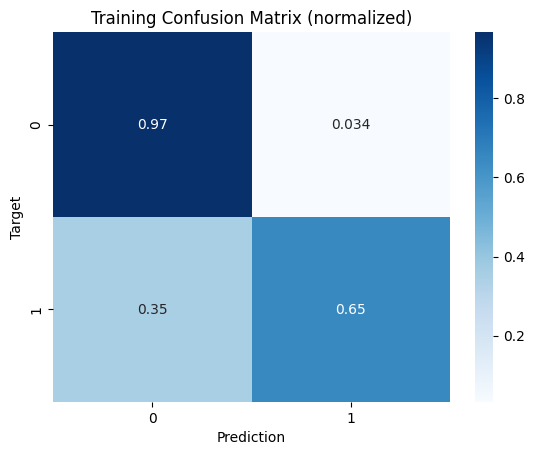

In [11]:
predict_and_plot(train_targets, train_preds, 'Training')

In [12]:
val_preds, val_probs, val_roc_auc  = evaluate_model(X_val, val_targets, model, 'Validation')

F1 score Validation: 0.62
AUROC for Validation: 0.86


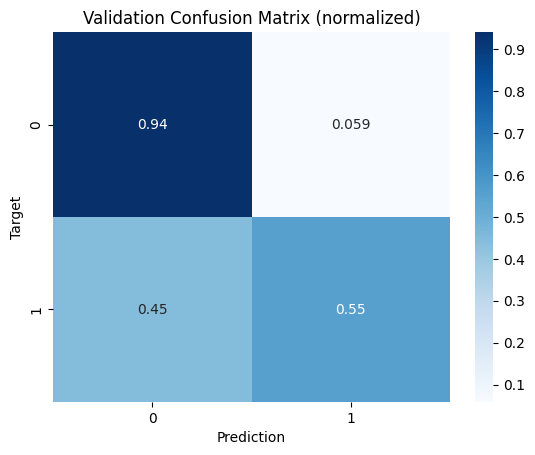

In [13]:
predict_and_plot(val_targets, val_preds, 'Validation')

***Висновок:***
- метрики показують, що побудована модель є посередньою з явними ознаками перенавчання.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [14]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5, scoring='roc_auc')
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

Важливо:

Хоча в завданні і не вкзано про заміну параметра scoring, все ж вважаю, що його правильно буде змінити.

Без зміни цього параметру отримую трохи гірші значення моделі по AUROC (спостерігається перенавчання, хоча і є незначне покращення в порівнянні з завданням №1) та відповідно інше значення оптимального параметру:

{'n_neighbors': np.int64(7)} 0.8683555555555555

F1 score Training: 0.71
AUROC for Training: 0.95

F1 score Validation: 0.62
AUROC for Validation: 0.88


In [15]:
knn_best = knn_gs.best_estimator_


In [16]:
print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(21)} 0.8835113890443484


In [17]:
train_preds, train_probs, train_roc_auc = evaluate_model(X_train, train_targets, knn_best, 'Training')

F1 score Training: 0.61
AUROC for Training: 0.92


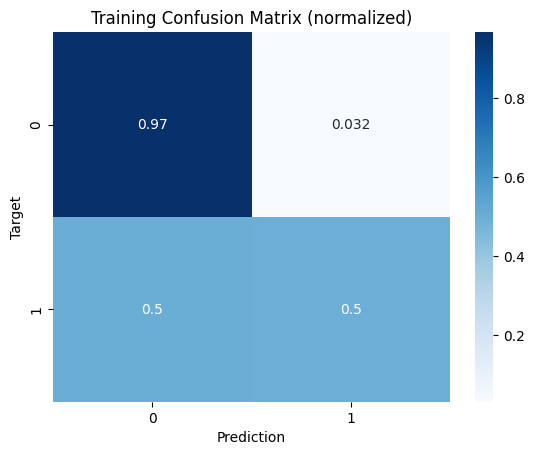

In [18]:
predict_and_plot(train_targets, train_preds, 'Training')

In [19]:
val_preds, val_probs, val_roc_auc  = evaluate_model(X_val, val_targets, knn_best, 'Validation')

F1 score Validation: 0.60
AUROC for Validation: 0.89


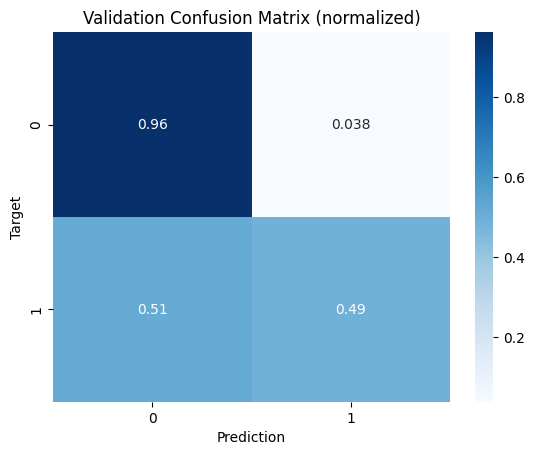

In [20]:
predict_and_plot(val_targets, val_preds, 'Validation')

***Висновок:***
- В порівнянні з моделлю в завданні №1 побудована модель стала кращою з точки зору відсутності перенавчання. Так різниця по AUROC між тренувальним наборм та валідаційним становить лише 3%.
- В порівнянні з моделлю дерева прийняття рішень з попереднього ДЗ побудована модель є гірншою. В тому ДЗ в мене була наступна оцінака AUROC:

    - max_depth: 5
    - AUROC for Training: 0.93
    - AUROC for Validation: 0.92


3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [21]:
%%time
tree_model = DecisionTreeClassifier(random_state=42)
params_tree = {'max_depth': np.arange(1, 20, 2), 'max_leaf_nodes' : np.arange(2, 10, 1)}
tree_gs = GridSearchCV(tree_model, params_tree, cv=3, scoring='roc_auc')
start_searcjing = time.time()
tree_gs.fit(X_train, train_targets)
end_searching = time.time()

CPU times: user 6.89 s, sys: 16.4 ms, total: 6.91 s
Wall time: 12.6 s


In [22]:
time_searching = end_searching - start_searcjing
print(f'Пошук оптимальних гіперпараметрів потребує {round(time_searching, 2)} секунд.')

Пошук оптимальних гіперпараметрів потребує 12.63 секунд.


In [23]:
dt_best = tree_gs.best_estimator_

In [24]:
print(tree_gs.best_params_, tree_gs.best_score_)

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(9)} 0.8948407274686595


In [25]:
train_preds, train_probs, train_roc_auc = evaluate_model(X_train, train_targets, dt_best, 'Training')

F1 score Training: 0.65
AUROC for Training: 0.90


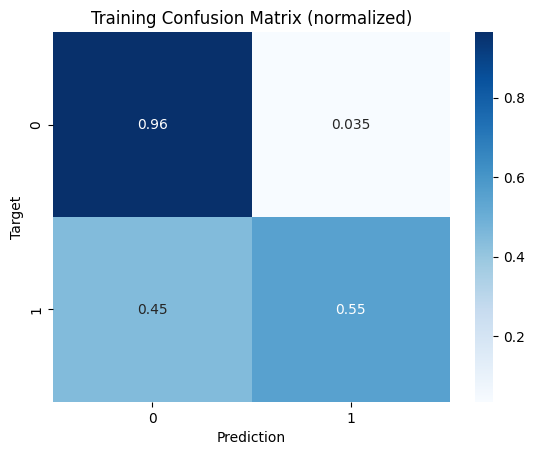

In [26]:
predict_and_plot(train_targets, train_preds, 'Training')

In [27]:
val_preds, val_probs, val_roc_auc  = evaluate_model(X_val, val_targets, dt_best, 'Validation')

F1 score Validation: 0.64
AUROC for Validation: 0.90


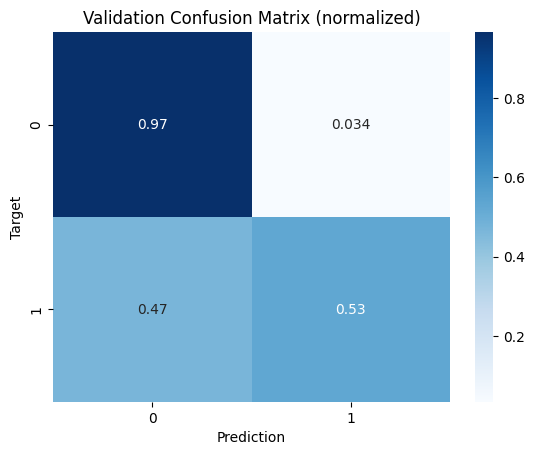

In [28]:
predict_and_plot(val_targets, val_preds, 'Validation')

***Висновок:***

- В порівнянні з ручним підбором парамеру в минулому ДЗ (в ній не було обмеженя по параметру кількості листків max_leaf_nodes), показники поточної моделі виявилися трохи нижчими:
        В тому ДЗ в мене була наступна оцінака AUROC:

    - max_depth: 5
    - AUROC for Training: 0.93
    - AUROC for Validation: 0.92

- Незважаючи на зниження оцінки по AUROC в порівнянні з минулим ДЗ, поточна модель демонструє свою стабільність на нових даних - значення AUROC на тестових та валідаційних наборах рівні.



4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [29]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [30]:
tree_model_2 = DecisionTreeClassifier(random_state=42)

search = RandomizedSearchCV(
    tree_model_2,
    params_dt,
    n_iter = 40,
    cv=3,
    scoring="roc_auc",
    random_state=42
)

In [31]:
%%time
search.fit(X_train, train_targets)

CPU times: user 2.32 s, sys: 4.09 ms, total: 2.33 s
Wall time: 3.48 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [32]:
dt_random_search_best = search.best_estimator_

In [33]:
print(search.best_params_, search.best_score_)

{'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'} 0.9118622813318175


In [34]:
train_preds, train_probs, train_roc_auc = evaluate_model(X_train, train_targets, dt_random_search_best, 'Training')

F1 score Training: 0.70
AUROC for Training: 0.92


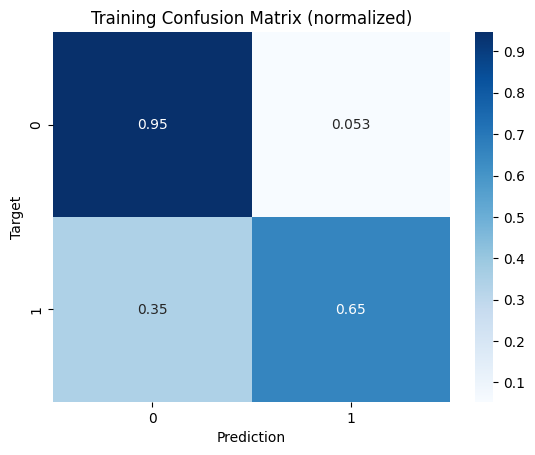

In [35]:
predict_and_plot(train_targets, train_preds, 'Training')

In [36]:
val_preds, val_probs, val_roc_auc  = evaluate_model(X_val, val_targets, dt_random_search_best, 'Validation')

F1 score Validation: 0.69
AUROC for Validation: 0.92


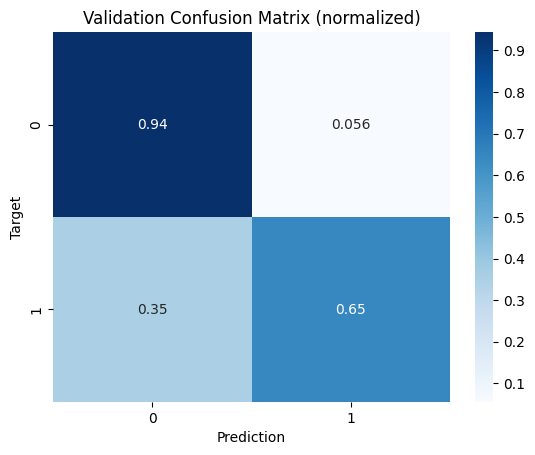

In [37]:
predict_and_plot(val_targets, val_preds, 'Validation')

***Висновок:***
- Отримана модель є кращою за ту, яку було знайдено з GridSearch. Ефект перенавчання відсутній. Значення метрики AUROC  як для навчального, так і валідаційного набору є вищою.

- Відносно кращих параметрів:

    - 'splitter': 'best'  був використаний для моделі з RandomizedSearchCV,як найкращий, а для GridSearch як "за замовчуванням" в DecisionTreeClassifier;
    - 'min_samples_split': 20 був  використаний для моделі з RandomizedSearchCV,як найкращий, а для GridSearch як   "2 -  за замовчуванням" в DecisionTreeClassifier;
    - 'min_samples_leaf': 2 був  використаний для моделі з RandomizedSearchCV,як найкращий, а для GridSearch як   "1 - за замовчуванням" в DecisionTreeClassifier;
    - 'max_leaf_nodes': np.int64(14) був  використаний для моделі з RandomizedSearchCV,як найкращий, а для GridSearch як   "9" в DecisionTreeClassifier;
    - 'max_features': None був  використаний для моделі з RandomizedSearchCV,як найкращий, а для GridSearch як   "None - за замовчуванням" в DecisionTreeClassifier;
    - 'max_depth': np.int64(16) був  використаний для моделі з RandomizedSearchCV, як найкращий, а для GridSearch як   "5" в DecisionTreeClassifier;
    - 'criterion': 'entropy'  був  використаний для моделі з RandomizedSearchCV, як найкращий, а для GridSearch як   "gini - за замовчуванням" в DecisionTreeClassifier.

Тобто вищезазначені значення параметрів десь послабили/зробили жорсткішими критерії побудови дерева, як наслідок отримана модель не має ефекту перенавчання та показує ідентичне значення AUROC на валідаційному наборі, що говорить про її робустність.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [38]:
test_raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [39]:
inputs = preprocess_new_data(test_raw_df, data['imputer_num'], data['imputer_cat'], data['encoder'], data['scaler'], data['numeric_cols'], data['categorical_cols'])
test_preds = dt_random_search_best.predict(inputs)
test_proba = dt_random_search_best.predict_proba(inputs)[:, 1]

test_raw_df['Exited'] = test_proba
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.231405
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.012522
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.202765
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.564065
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.080196


In [40]:
submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')
submission_df.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [41]:
submission_df['Exited'] = test_raw_df['Exited']
submission_df.head()

,id,Exited
0,15000,0.231405
1,15001,0.012522
2,15002,0.202765
3,15003,0.564065
4,15004,0.080196


In [42]:
submission_df.to_csv('submission_log_reg.csv', index=False)

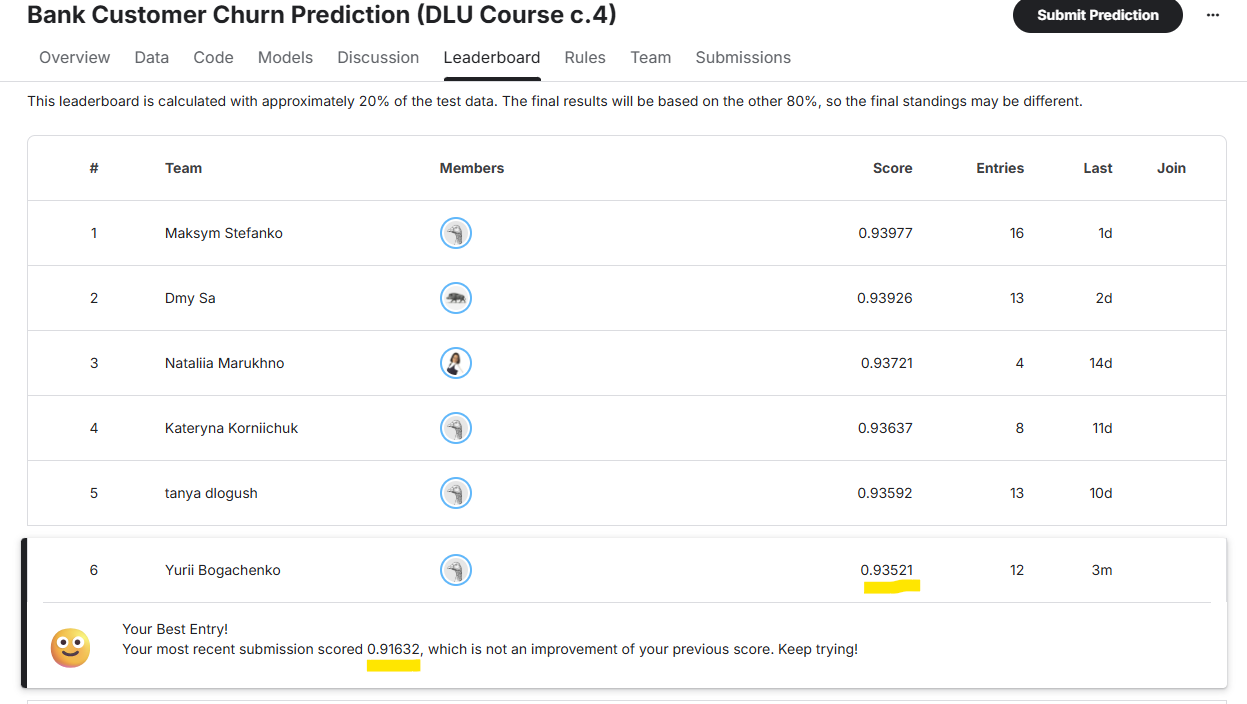